In [55]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn

6980.33s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


6985.98s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


6991.45s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


6996.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [57]:
import os

file_path = "/Users/alex/delivery-delay-analysis/data/processed/Delay_rate_by_category.csv"

if not os.path.exists(file_path):
    print(f"Error: The File '{file_path}' does not exist ")
else:
    try:
        df = pd.read_csv(
            file_path,
            on_bad_lines ="skip",
            encoding = 'utf-8'
        )
        print("CSV loaded successfully")
        print(df.head())
    except pd.errors.EmptyDataError:
        print("Error: The CSV is empty")
    except pd.errors.ParserError as e:
        print(f"Error: Parse error (structrally corrupt CSV) {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        

CSV loaded successfully
  product_category_name  delivered_orders  delayed_orders  delay_rate
0                  auto             73712            7357        9.98
1               fashion            446008           44298        9.93
2                  toys            234241           23107        9.86
3                 books            183776           18100        9.85
4             furniture            184558           18142        9.83


In [58]:
df.head()

,product_category_name,delivered_orders,delayed_orders,delay_rate
0,auto,73712,7357,9.98
1,fashion,446008,44298,9.93
2,toys,234241,23107,9.86
3,books,183776,18100,9.85
4,furniture,184558,18142,9.83


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_category_name  7 non-null      str    
 1   delivered_orders       7 non-null      int64  
 2   delayed_orders         7 non-null      int64  
 3   delay_rate             7 non-null      float64
dtypes: float64(1), int64(2), str(1)
memory usage: 356.0 bytes


In [60]:
df.describe()

,delivered_orders,delayed_orders,delay_rate
count,7.000000,7.000000,7.000000
mean,293441.000000,28848.714286,9.854286
std,189936.359531,18539.430230,0.081006
min,73712.000000,7357.000000,9.740000
25%,184167.000000,18121.000000,9.810000
50%,234241.000000,23107.000000,9.850000
75%,370783.500000,36621.000000,9.895000
max,636233.000000,61993.000000,9.980000


In [61]:
# missing data check
df.isna().sum()

product_category_name    0
delivered_orders         0
delayed_orders           0
delay_rate               0
dtype: int64

In [62]:
# no missing data and go to the next step
df.rename(columns={'product_category_name':'category'},inplace=True)


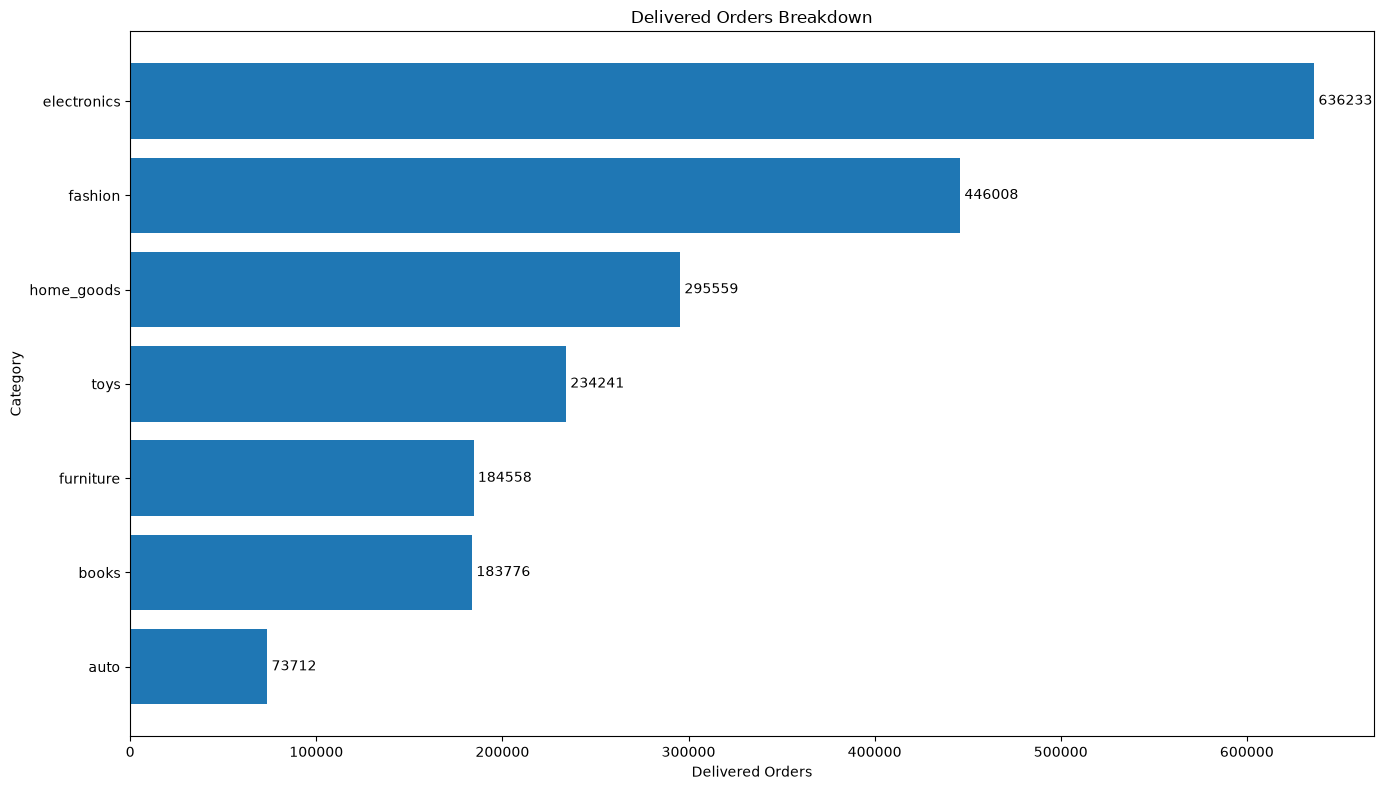

In [63]:
# delivered orders rank chart
df = df.sort_values(by='delivered_orders')
fig,ax = plt.subplots(figsize=(14,8))

bars = ax.barh(df['category'],df['delivered_orders'])

ax.bar_label(bars,padding=3)

ax.set_xlabel('Delivered Orders')
ax.set_ylabel('Category')
ax.set_title('Delivered Orders Breakdown')

plt.tight_layout()
plt.show()


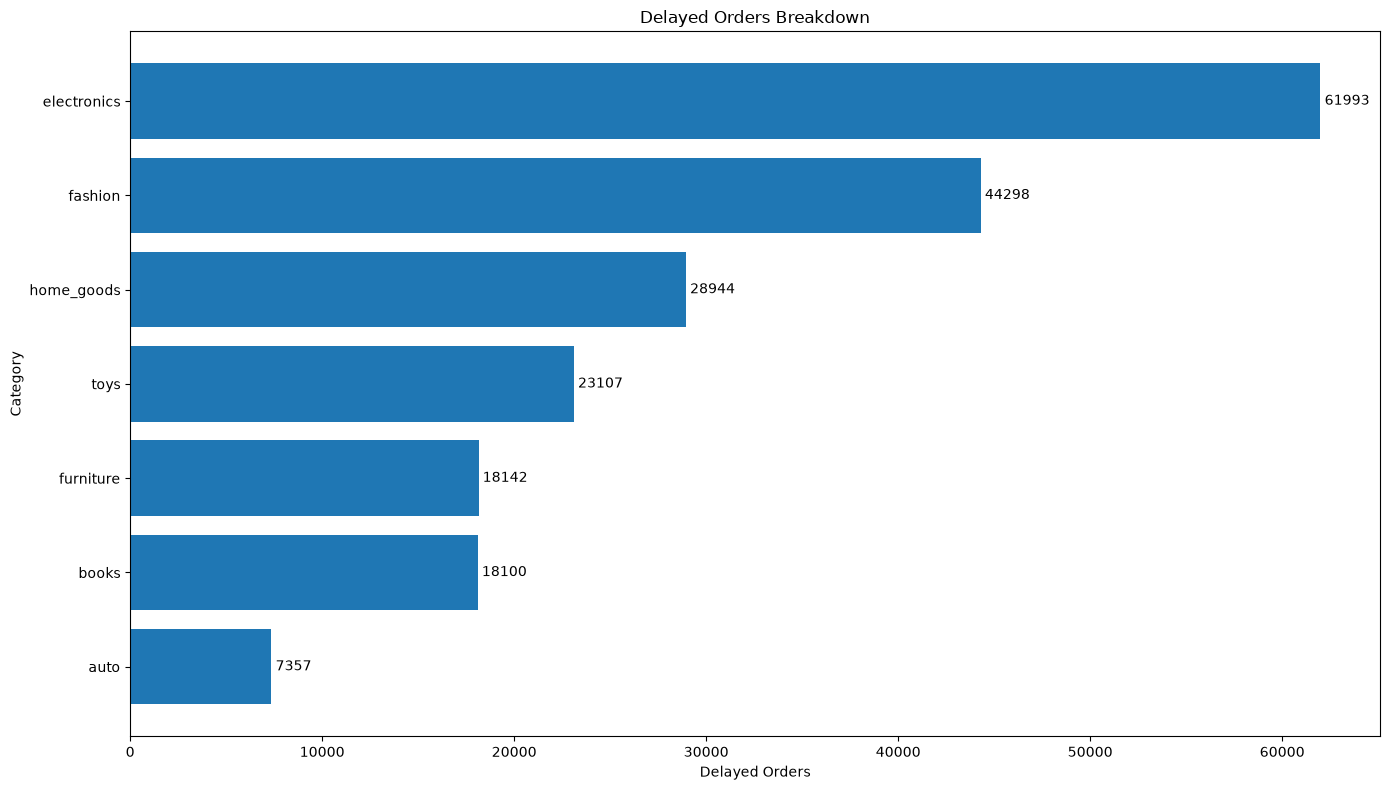

In [64]:
# delayed orders rank chart
df = df.sort_values(by='delayed_orders')
fig,ax = plt.subplots(figsize=(14,8))

bars = ax.barh(df['category'],df['delayed_orders'])

ax.bar_label(bars,padding=3)

ax.set_xlabel('Delayed Orders')
ax.set_ylabel('Category')
ax.set_title('Delayed Orders Breakdown')

plt.tight_layout()
plt.show()


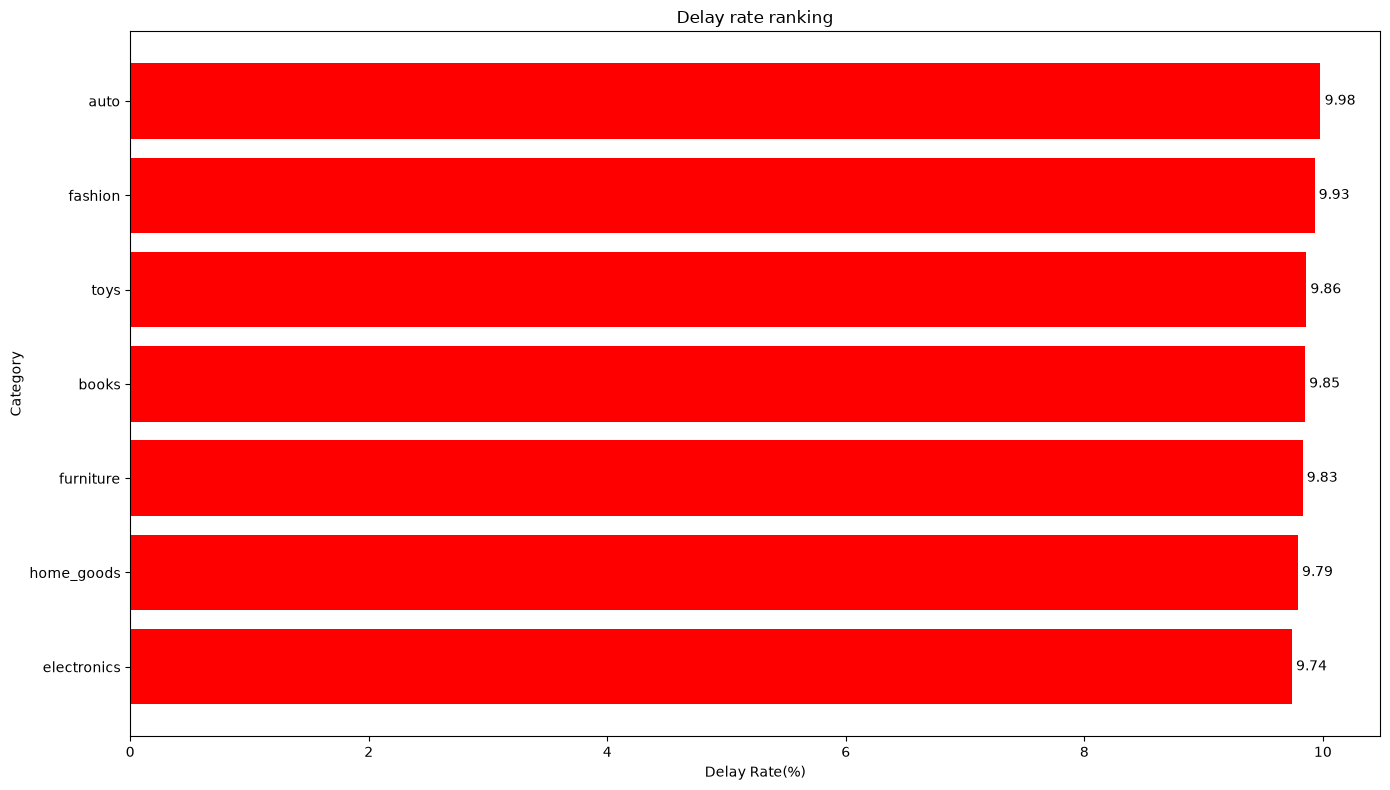

In [66]:
# delay rate rank chart
df = df.sort_values(by='delay_rate')
fig,ax = plt.subplots(figsize=(14,8))

bars = ax.barh(df['category'],df['delay_rate'],color='red')

ax.bar_label(bars,padding=3)

ax.set_xlabel('Delay Rate(%)')
ax.set_ylabel('Category')
ax.set_title('Delay rate ranking')

plt.tight_layout()
plt.show()
